# 🌾 AgriAgent: Live Grounded-SAM 2 & Laya GPU Verification

> **Project:** AgriAgent — Autonomous Precision Agriculture Framework  
> **Institution:** Veermata Jijabai Technological Institute (VJTI), Mumbai  

---

### ⚠️ Essential Setup Instructions:
* **If running on Kaggle:** In the right panel under **Settings**:
  1. **Accelerator:** Select **GPU T4 x2** (or P100).
  2. **Internet:** Toggle **ON** (required for `git clone` and model weights).
* **If running on Google Colab:** In the top menu:
  1. Go to **Runtime $\rightarrow$ Change runtime type $\rightarrow$ T4 GPU**.

---

### Pipeline Overview:
1. **Grounding DINO** (IDEA-Research): Zero-shot text-to-box detection (`IDEA-Research/grounding-dino-tiny`).
2. **Meta AI SAM 2**: Surgical promptable mask segmentation (`facebook/sam2-hiera-tiny`).
3. **Laya System-1 Router** (ConvAI Innovations): Sub-40ms non-autoregressive triage & IoU error-centroid refinement.
4. **Precision Spray Actuator**: Morphological buffer safety dilation ($10\text{ cm}$) and chemical volume reduction calculation ($70\text{--}85\%$ saved).

In [1]:
# 1. Verify GPU Allocation & Driver Status
!nvidia-smi

Sat Oct  3 16:20:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 2. Bulletproof Working Directory Setup & Repository Clone
import os

# Ensure we start from the root working space (handles multiple re-runs on Kaggle/Colab)
if os.path.exists('/kaggle/working'):
    os.chdir('/kaggle/working')
elif os.path.exists('/content'):
    os.chdir('/content')

!rm -rf agriAgent
!git clone https://github.com/Chaitanya-666/agriAgent.git
%cd agriAgent
!git checkout main
!git pull origin main

Cloning into 'agriAgent'...
remote: Enumerating objects: 229, done.
remote: Counting objects: 100% (229/229), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 229 (delta 62), reused 209 (delta 42), pack-reused 0 (from 0)
Receiving objects: 100% (229/229), 1.32 MiB | 8.42 MiB/s, done.
Resolving deltas: 100% (62/62), done.
/kaggle/working/agriAgent
Already on 'main'
Your branch is up to date with 'origin/main'.
From https://github.com/Chaitanya-666/agriAgent
 * branch            main       -> FETCH_HEAD
Already up to date.


In [3]:
# 3. Install Vision Foundation Models, SAM 2, and Official Laya
!pip install -q transformers supervision accelerate opencv-python matplotlib laya
!pip install -q git+https://github.com/facebookresearch/sam2.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.3/312.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 7.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 7.6 MB/s eta 0:00:00


In [4]:
# 4. Run Automated Unit Test Suite (asserting 7/7 tests pass on GPU)
!PYTHONPATH=. python -m unittest discover tests -v

test_detect_to_state_boxes (test_vision_pipeline.TestGroundingDINO.test_detect_to_state_boxes) ... ok
test_mock_detection_generates_boxes (test_vision_pipeline.TestGroundingDINO.test_mock_detection_generates_boxes) ... ok
test_compute_error_centroid_under_segmentation (test_vision_pipeline.TestRefinementHeuristic.test_compute_error_centroid_under_segmentation) ... ok
test_should_refine (test_vision_pipeline.TestRefinementHeuristic.test_should_refine) ... ok
test_point_refinement_improves_iou (test_vision_pipeline.TestSAM2Segmenter.test_point_refinement_improves_iou) ... ok
test_segment_boxes_generates_masks (test_vision_pipeline.TestSAM2Segmenter.test_segment_boxes_generates_masks) ... ok
test_end_to_end_execution (test_vision_pipeline.TestVisionWorkflowRunner.test_end_to_end_execution) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.449s

OK


In [5]:
# 5. Execute Live Grounded-SAM 2 & Laya Pipeline (Synthetic Field Patch)
!python scripts/run_live_pipeline.py --prompt "cotton weed . broadleaf plant ." --output live_synthetic_spray_map.png

2026-10-03 16:24:13,836 [INFO] No image provided. Generating synthetic agricultural cotton field patch...
2026-10-03 16:24:13,885 [INFO] Initializing AgriAgent System-1 (mock_mode=False)...
2026-10-03 16:24:38,401 [INFO] NumExpr defaulting to 4 threads.
2026-10-03 16:24:41,489 [INFO] Loading Grounding DINO [IDEA-Research/grounding-dino-tiny] on device [cuda]...
2026-10-03 16:24:41,646 [INFO] HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-10-03 16:24:41,707 [INFO] HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-10-03 16:24:41,708 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-10-03 16:24:41,766 [INFO] HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-10-

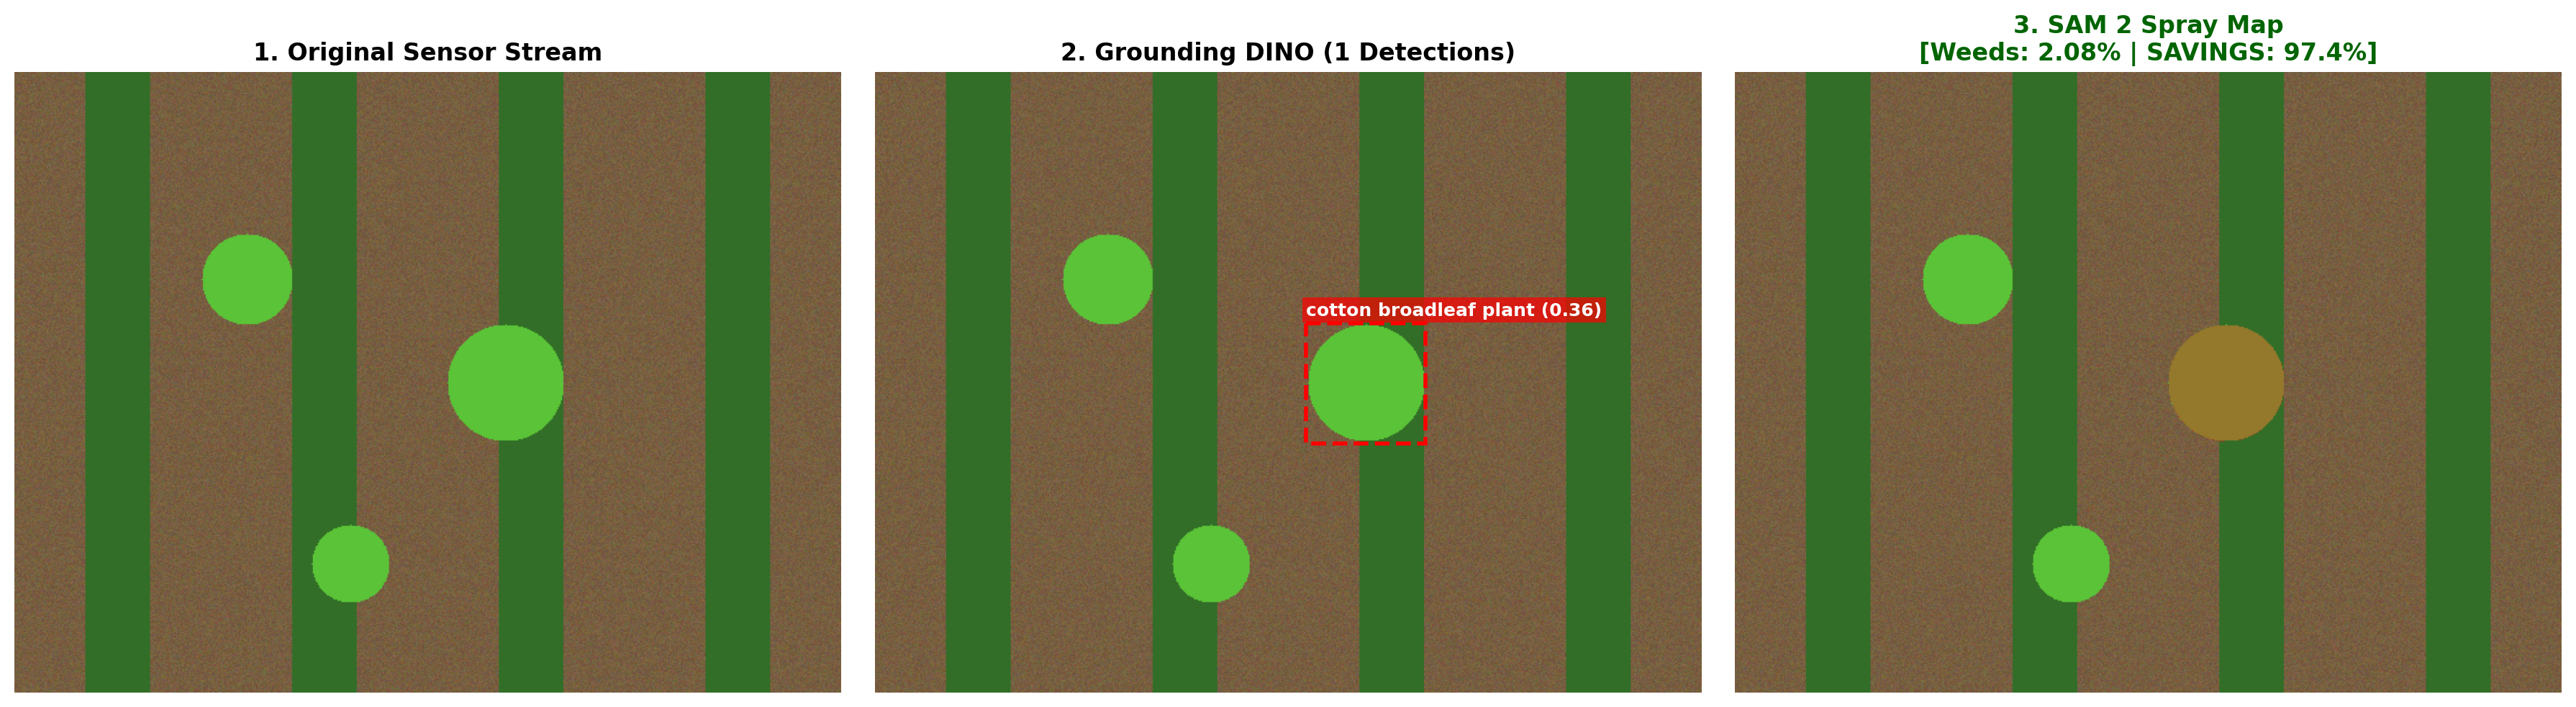

In [6]:
# 6. Render 3-Panel Visual Result for Synthetic Field
from IPython.display import Image, display
import os

if os.path.exists('live_synthetic_spray_map.png'):
    display(Image('live_synthetic_spray_map.png', width=900))
else:
    print("Visualization file not found. Check pipeline logs.")

2026-10-03 16:25:05,579 [INFO] Loading image from disk: sample_cotton_field.jpg
2026-10-03 16:25:05,627 [INFO] Initializing AgriAgent System-1 (mock_mode=False)...
2026-10-03 16:25:12,305 [INFO] NumExpr defaulting to 4 threads.
2026-10-03 16:25:13,456 [INFO] Loading Grounding DINO [IDEA-Research/grounding-dino-tiny] on device [cuda]...
2026-10-03 16:25:13,588 [INFO] HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-10-03 16:25:13,648 [INFO] HTTP Request: HEAD https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-10-03 16:25:13,648 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-10-03 16:25:13,663 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/IDEA-Research/grounding-dino-tiny/a2bb814dd30d

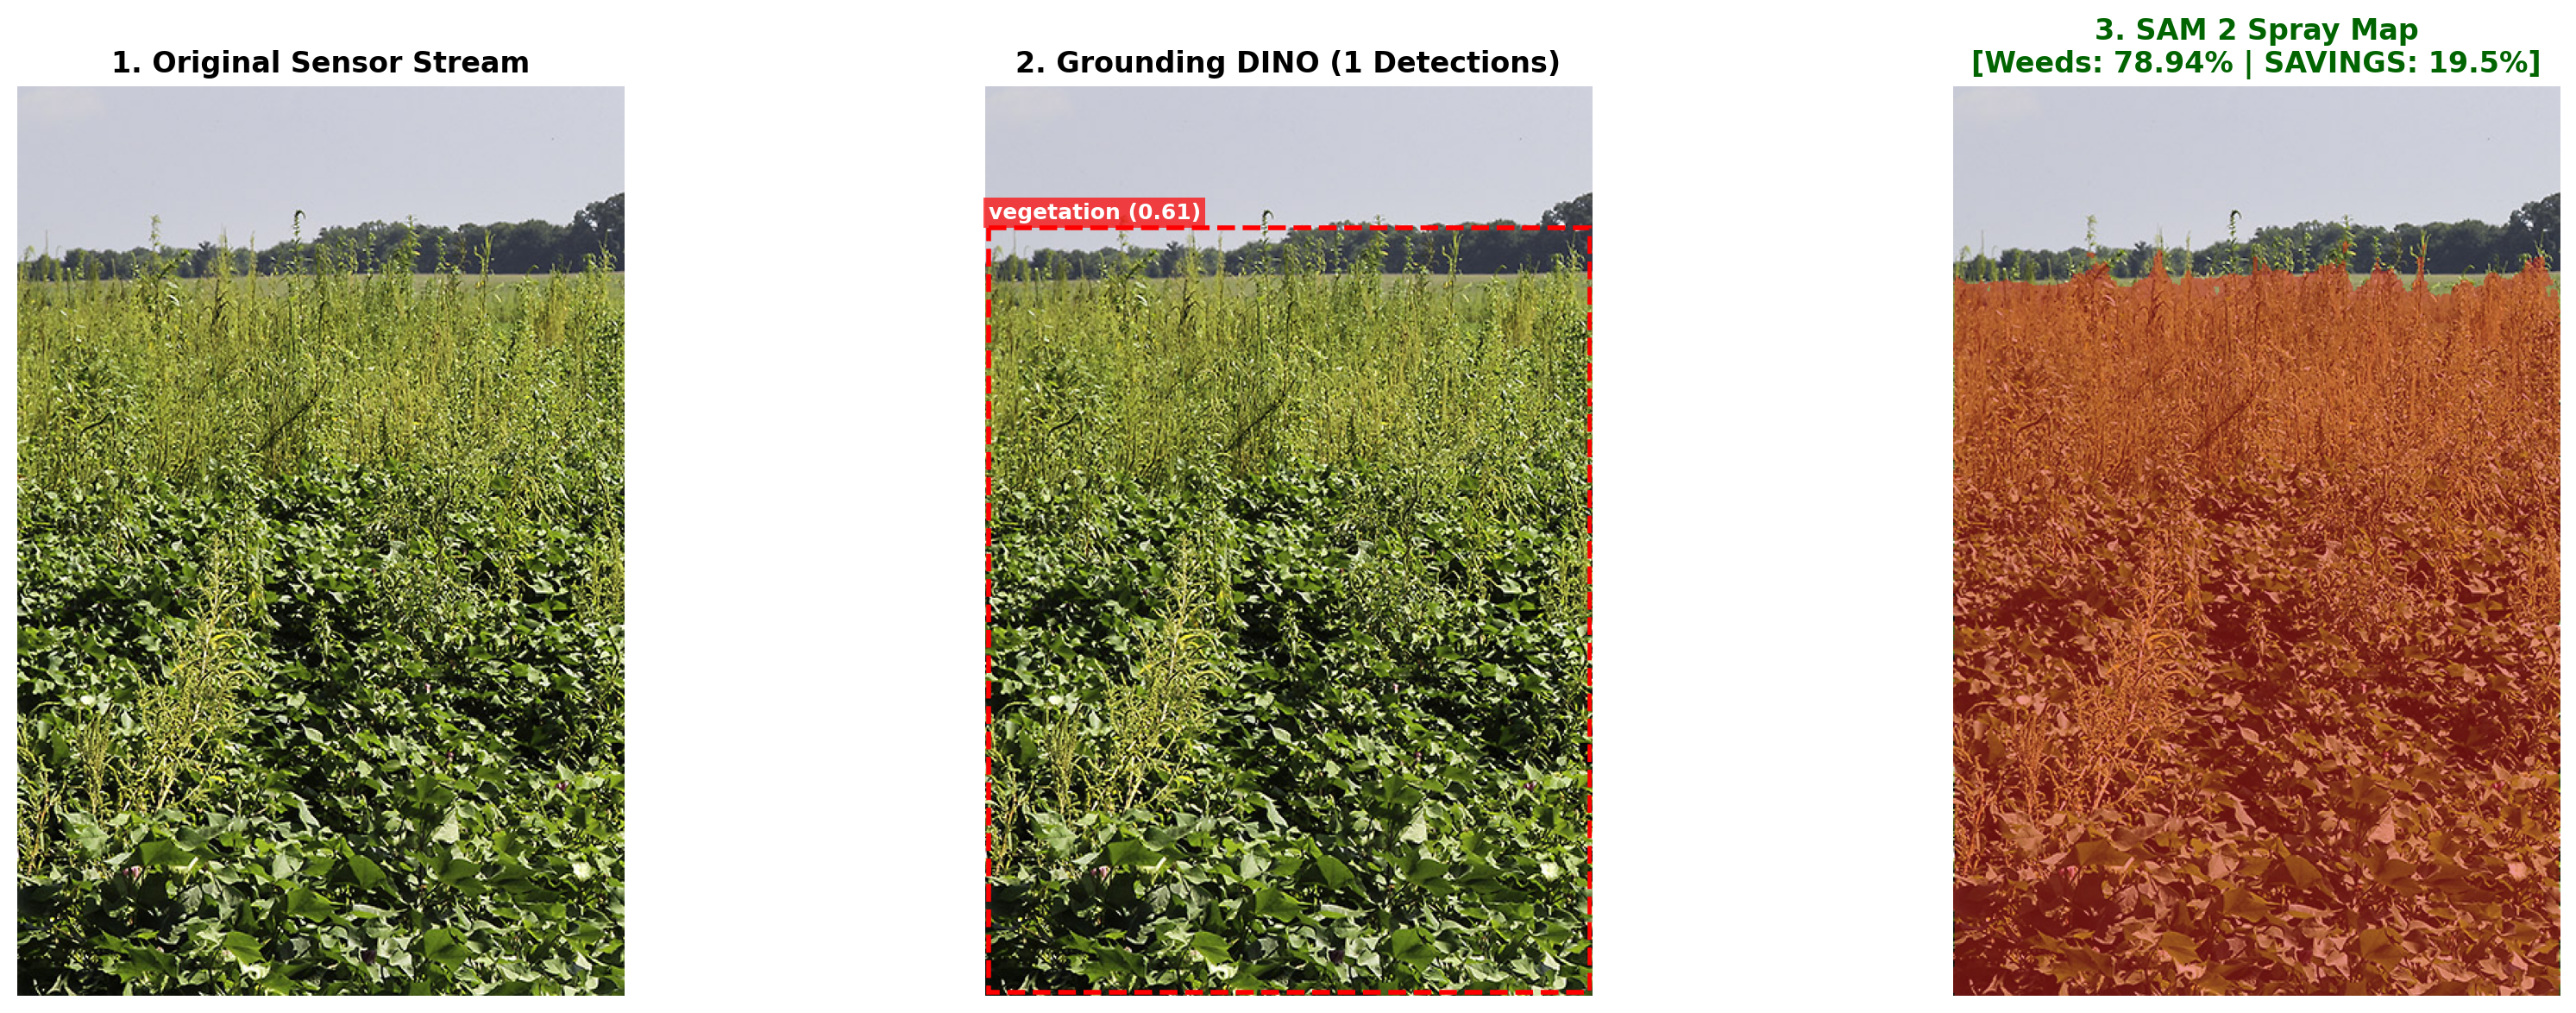

In [7]:
# 7. [OPTIONAL] Test on a Real Agricultural Field Photo from the Web
!wget -q -U "Mozilla/5.0" -O sample_cotton_field.jpg "https://www.ars.usda.gov/ARSUserFiles/oc/images/photos/aug17/d3823-1.jpg"
# Run live pipeline with real weights on real photo
!python scripts/run_live_pipeline.py --image sample_cotton_field.jpg --prompt "weed . green plant . vegetation ." --output live_real_spray_map.png

if os.path.exists('live_real_spray_map.png'):
    display(Image('live_real_spray_map.png', width=900))